In [ ]:
pip install pandas numpy nltk matplotlib seaborn scikit-learn gensim wordcloud torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

Data loaded successfully. Number of records: 18408
Columns found: ['Comment', 'Sentiment']
Sentiment analysis completed.
Text classification (clustering) completed. Cluster labels assigned.
Cluster 0 top terms: good, great, time, im, really, best, que, people, thanks, amazing
Cluster 1 top terms: video, thank, great, videos, really, thanks, im, good, time, just
Cluster 2 top terms: love, videos, song, just, great, really, content, video, good, work
Cluster 3 top terms: years, guy, ago, old, time, just, ive, im, like, good
Cluster 4 top terms: like, just, feel, really, people, im, know, time, dont, good
Top 20 trending words:
like: 2633
love: 2151
one: 2012
video: 1943
really: 1649
time: 1542
thank: 1509
great: 1503
much: 1456
get: 1416
good: 1412
would: 1330
people: 1250
dont: 1151
see: 1100
videos: 1086
know: 1078
always: 1038
make: 1037
also: 997


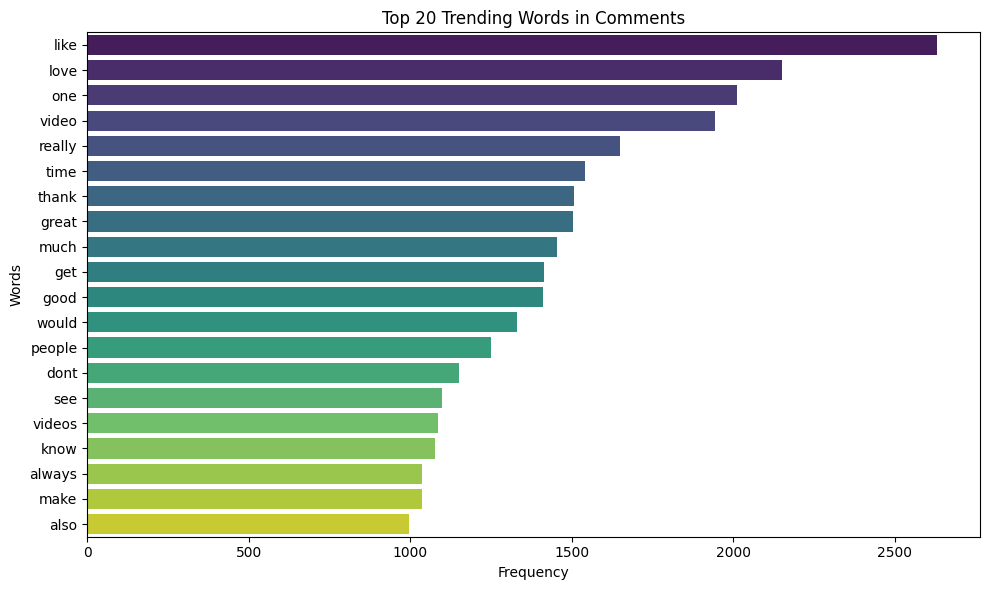

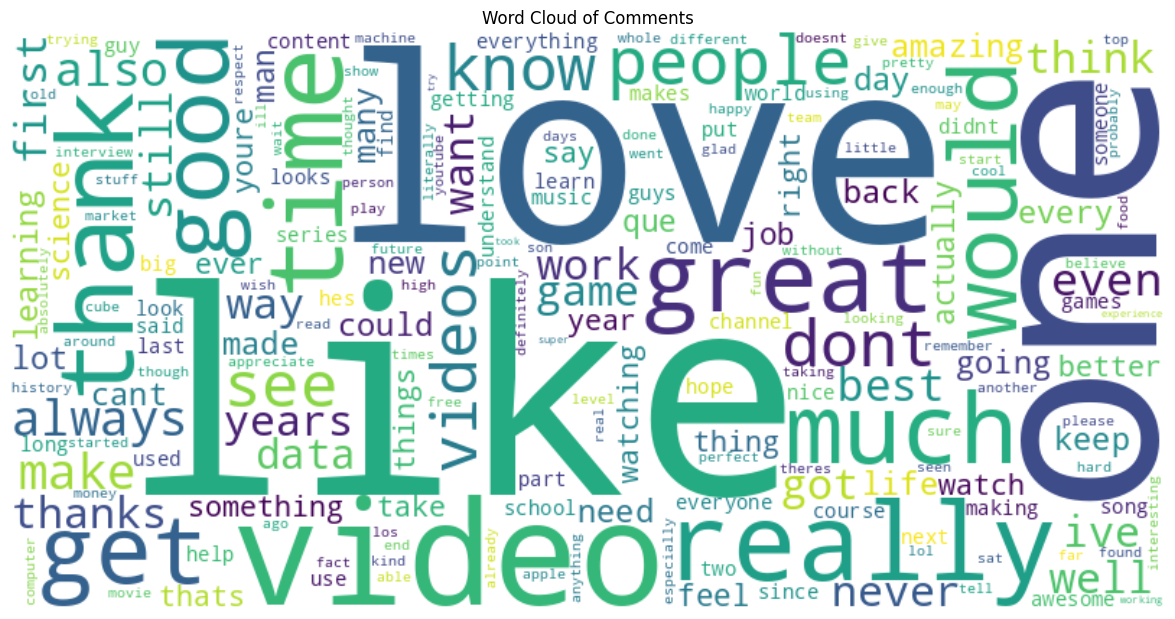

Date column 'date' not found. Skipping user behavior analysis.
Topic Modeling (LDA) Results:
(0, '0.020*"que" + 0.006*"para" + 0.006*"por" + 0.005*"bias" + 0.005*"como" + 0.005*"gracias" + 0.004*"con" + 0.004*"andrew" + 0.004*"weighted" + 0.003*"ser"')
(1, '0.031*"love" + 0.013*"great" + 0.011*"like" + 0.011*"good" + 0.010*"really" + 0.009*"videos" + 0.009*"see" + 0.008*"video" + 0.008*"keep" + 0.008*"amazing"')
(2, '0.015*"learning" + 0.013*"thank" + 0.012*"video" + 0.011*"data" + 0.010*"like" + 0.008*"much" + 0.007*"really" + 0.007*"machine" + 0.007*"thanks" + 0.006*"would"')
(3, '0.011*"one" + 0.009*"get" + 0.006*"best" + 0.006*"game" + 0.006*"like" + 0.006*"games" + 0.005*"would" + 0.005*"great" + 0.005*"series" + 0.004*"think"')
(4, '0.010*"movie" + 0.008*"son" + 0.008*"engineer" + 0.008*"los" + 0.006*"teach" + 0.006*"models" + 0.006*"mejores" + 0.005*"conciertos" + 0.005*"tan" + 0.005*"hermosa"')

Transformation Results (Sample of Negative Comments):
 Index                       

In [ ]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from collections import Counter
from wordcloud import WordCloud
from gensim import corpora, models

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Suppress TF warnings (if any) – not needed here, but for cleanliness.
os.environ['PYTHONWARNINGS'] = 'ignore'

# Download required NLTK data
nltk.download('stopwords', quiet=True)

########################################
# 1. Data Loading
########################################
def load_data(csv_file):

    try:
        df = pd.read_csv(csv_file)
        print(f"Data loaded successfully. Number of records: {len(df)}")
        print("Columns found:", df.columns.tolist())
        return df
    except Exception as e:
        print("Error loading data:", e)
        return None

########################################
# 2. Text Vectorization (Character-Level)
########################################
class TextVectorizer:
    def __init__(self, sequence_length):
        self.sequence_length = sequence_length
        self.char_to_idx = {}
        self.idx_to_char = {}
        self.vocab_size = 0

    def adapt(self, texts):

        chars = set()
        for text in texts:
            for c in text.lower():
                chars.add(c)
        sorted_chars = sorted(list(chars))
        # Reserve 0 for PAD, 1 for UNK; vocabulary indices start at 2.
        self.char_to_idx = {c: i+2 for i, c in enumerate(sorted_chars)}
        self.idx_to_char = {i+2: c for i, c in enumerate(sorted_chars)}
        self.char_to_idx["<PAD>"] = 0
        self.char_to_idx["<UNK>"] = 1
        self.idx_to_char[0] = "<PAD>"
        self.idx_to_char[1] = "<UNK>"
        self.vocab_size = len(self.char_to_idx)
        print(f"Vocabulary built: {self.vocab_size} tokens.")

    def vectorize(self, text):
        """
        Converts a text string to a list of integer indices.
        Pads or truncates to self.sequence_length.
        """
        text = text.lower()
        indices = [self.char_to_idx.get(c, 1) for c in text]
        if len(indices) < self.sequence_length:
            indices = indices + [0] * (self.sequence_length - len(indices))
        else:
            indices = indices[:self.sequence_length]
        return indices

########################################
# 3. PyTorch Dataset for Sentiment Classification
########################################
class SentimentDataset(Dataset):
    def __init__(self, df, text_vectorizer, label_map, text_column="Comment"):
        self.df = df.reset_index(drop=True)
        self.text_vectorizer = text_vectorizer
        self.label_map = label_map
        self.text_column = text_column

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = self.df.loc[idx, self.text_column]
        vector = self.text_vectorizer.vectorize(text)
        label = self.df.loc[idx, "label"]  # assumes a "label" column exists (mapped to int)
        return torch.tensor(vector, dtype=torch.long), torch.tensor(label, dtype=torch.long)

########################################
# 4. GRU-Based Sentiment Classifier (PyTorch)
########################################
class GRUSentimentClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes):
        super(GRUSentimentClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch_size, sequence_length)
        embedded = self.embedding(x)  # (batch_size, sequence_length, embedding_dim)
        output, hidden = self.gru(embedded)  # hidden: (1, batch_size, hidden_size)
        logits = self.fc(hidden.squeeze(0))  # (batch_size, num_classes)
        return logits

########################################
# 5. Training Loop for the Sentiment Model
########################################
def train_model(model, train_loader, valid_loader, epochs, device):
    optimizer = torch.optim.Adam(model.parameters())
    criterion = nn.CrossEntropyLoss()
    best_valid_acc = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
        train_loss /= total
        train_acc = correct / total

        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for x, y in valid_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                valid_loss += loss.item() * x.size(0)
                preds = torch.argmax(logits, dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)
        valid_loss /= total
        valid_acc = correct / total

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")

        # Save best model checkpoint
        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            torch.save(model.state_dict(), "best_sentiment_model.pt")
    print("Training complete. Best validation accuracy: {:.4f}".format(best_valid_acc))

########################################
# 6. Prediction Function
########################################
def predict_sentiment(model, text, text_vectorizer, device):
    model.eval()
    vector = text_vectorizer.vectorize(text)
    x = torch.tensor(vector, dtype=torch.long).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        score, pred = torch.max(probs, dim=1)
        label_map_inv = {0: "Negative", 1: "Neutral", 2: "Positive"}
        return score.item(), label_map_inv[pred.item()]

########################################
# 7. Additional Analyses (Trend, Topic Modeling, Style Transformation)
########################################
def trend_analysis(df, text_column='Comment'):
    """
    Analyzes overall word frequencies and displays a bar chart and a word cloud.
    """
    from nltk.corpus import stopwords
    stops = set(stopwords.words('english'))

    text = " ".join(df[text_column].astype(str).tolist()).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stops and len(w) > 2]
    word_counts = Counter(words)
    top_words = word_counts.most_common(20)
    print("Top 20 trending words:")
    for word, count in top_words:
        print(f"{word}: {count}")
    words_bar, counts_bar = zip(*top_words)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts_bar), y=list(words_bar), palette="viridis")
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.title("Top 20 Trending Words in Comments")
    plt.tight_layout()
    plt.show()
    wordcloud = WordCloud(width=800, height=400, background_color="white")\
                .generate_from_frequencies(word_counts)
    plt.figure(figsize=(15, 7.5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Comments")
    plt.show()

def topic_modeling(df, text_column='Comment', num_topics=5):
    """
    Applies LDA topic modeling to the comments and assigns a dominant topic.
    """
    from nltk.corpus import stopwords
    stops = set(stopwords.words('english'))
    def preprocess_text(text):
         text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
         tokens = text.split()
         tokens = [token for token in tokens if token not in stops and len(token) > 2]
         return tokens
    processed_docs = df[text_column].astype(str).apply(preprocess_text)
    dictionary = corpora.Dictionary(processed_docs)
    corpus = [dictionary.doc2bow(doc) for doc in processed_docs]
    lda_model = models.LdaModel(corpus, num_topics=num_topics, id2word=dictionary,
                                passes=10, random_state=42)
    print("Topic Modeling (LDA) Results:")
    topics = lda_model.print_topics(num_words=10)
    for topic in topics:
         print(topic)
    def get_dominant_topic(bow):
         topics = lda_model.get_document_topics(bow)
         if topics:
              dominant_topic = sorted(topics, key=lambda x: x[1], reverse=True)[0][0]
              return dominant_topic
         return None
    df['dominant_topic'] = [get_dominant_topic(doc) for doc in corpus]
    return df

def transform_comment(comment):
    """
    Applies simple rule-based replacements to rewrite negative expressions.
    """
    replacements = {
         r'\bfuck off\b': 'can you please go',
         r'\bfuck you\b': 'I kindly ask you to reconsider your approach',
         r'\bshut up\b': 'please be quiet'
    }
    new_comment = comment
    for pattern, replacement in replacements.items():
         new_comment = re.sub(pattern, replacement, new_comment, flags=re.IGNORECASE)
    return new_comment

def style_transform_negative_to_positive(negative_comment):
    """
    Transforms a negative comment by applying rule-based changes and appending a fixed positive phrase.
    """
    transformed = transform_comment(negative_comment)
    transformed = transformed + " Thank you for your feedback!"
    return transformed

def transform_negative_comments(df, text_column='Comment', n=10):
    """
    Finds up to n negative comments (based on predicted sentiment) and transforms each.
    Prints the results as a table and stores them in a new column.
    """
    negative_df = df[df['sentiment_label'] == 'Negative']
    if negative_df.empty:
         print("No negative comments found.")
         return df
    n = min(n, len(negative_df))
    transformed_list = []
    sample_negative = negative_df.sample(n)
    for idx, row in sample_negative.iterrows():
         neg_comment = row[text_column]
         transformed_comment = style_transform_negative_to_positive(neg_comment)
         transformed_list.append({
              "Index": idx,
              "Negative Comment": neg_comment,
              "Transformed Comment": transformed_comment
         })
         df.loc[idx, 'transformed_negative'] = transformed_comment
    transformed_df = pd.DataFrame(transformed_list)
    print("\nTransformation Results (Sample of Negative Comments):")
    print(transformed_df.to_string(index=False))
    return df

########################################
# 8. Main Function: Integration of All Tasks
########################################
def main():
    # Update the CSV file path if needed.
    csv_file = "amazon_reviews.csv"
    df = load_data(csv_file)
    if df is None:
         return

    # --- (A) Create a TextVectorizer using the Comment column.
    SEQUENCE_LENGTH = 200
    text_vectorizer = TextVectorizer(sequence_length=SEQUENCE_LENGTH)
    text_vectorizer.adapt(df["Comment"].values)

    # --- (B) Map sentiment labels to integers.
    # Expecting df["Sentiment"] contains "Negative", "Neutral", "Positive".
    label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
    if "Sentiment" in df.columns:
         df["label"] = df["Sentiment"].map(label_map)
    else:
         raise ValueError("No 'Sentiment' column found in the dataset.")

    # --- (C) Split into training and validation sets (80/20 split).
    train_df = df.sample(frac=0.8, random_state=42)
    valid_df = df.drop(train_df.index)

    train_dataset = SentimentDataset(train_df, text_vectorizer, label_map, text_column="Comment")
    valid_dataset = SentimentDataset(valid_df, text_vectorizer, label_map, text_column="Comment")

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=32)

    # --- (D) Build and train the GRU-based sentiment classifier.
    vocab_size = text_vectorizer.vocab_size
    print("Vocabulary size:", vocab_size)
    model = GRUSentimentClassifier(vocab_size=vocab_size,
                                   embedding_dim=16,
                                   hidden_size=128,
                                   num_classes=3)
    model = model.to(device)
    EPOCHS = 10
    train_model(model, train_loader, valid_loader, epochs=EPOCHS, device=device)

    # --- (E) Use the trained model to predict sentiment for all comments.
    def predict_sentiment_for_text(text):
         score, label = predict_sentiment(model, text, text_vectorizer, device)
         return score, label

    df["predicted_sentiment"] = df["Comment"].apply(lambda x: predict_sentiment_for_text(x)[1])
    df["sentiment_score"] = df["Comment"].apply(lambda x: predict_sentiment_for_text(x)[0])
    # Override sentiment_label with our predictions.
    df["sentiment_label"] = df["predicted_sentiment"]

    # --- (F) Perform Topic Modeling.
    df = topic_modeling(df, text_column="Comment", num_topics=5)

    # --- (G) Perform Trend Analysis.
    trend_analysis(df, text_column="Comment")

    # --- (H) Perform User Behavior Analysis (if a 'date' column exists).
    user_behavior_analysis(df, date_column="date")

    # --- (I) Apply Style Transformation for Negative Comments.
    df = transform_negative_comments(df, text_column="Comment", n=10)

    # --- (J) Save the augmented DataFrame.
    output_file = "amazon_reviews_augmented.csv"
    df.to_csv(output_file, index=False)
    print(f"\nAll analyses completed. Augmented data saved to '{output_file}'.")

if __name__ == "__main__":
    main()
